In [4]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [5]:
torch.manual_seed(42)

In [6]:
df = pd.read_csv('fmnist_small.csv')

In [8]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [9]:
df.shape

(6000, 785)

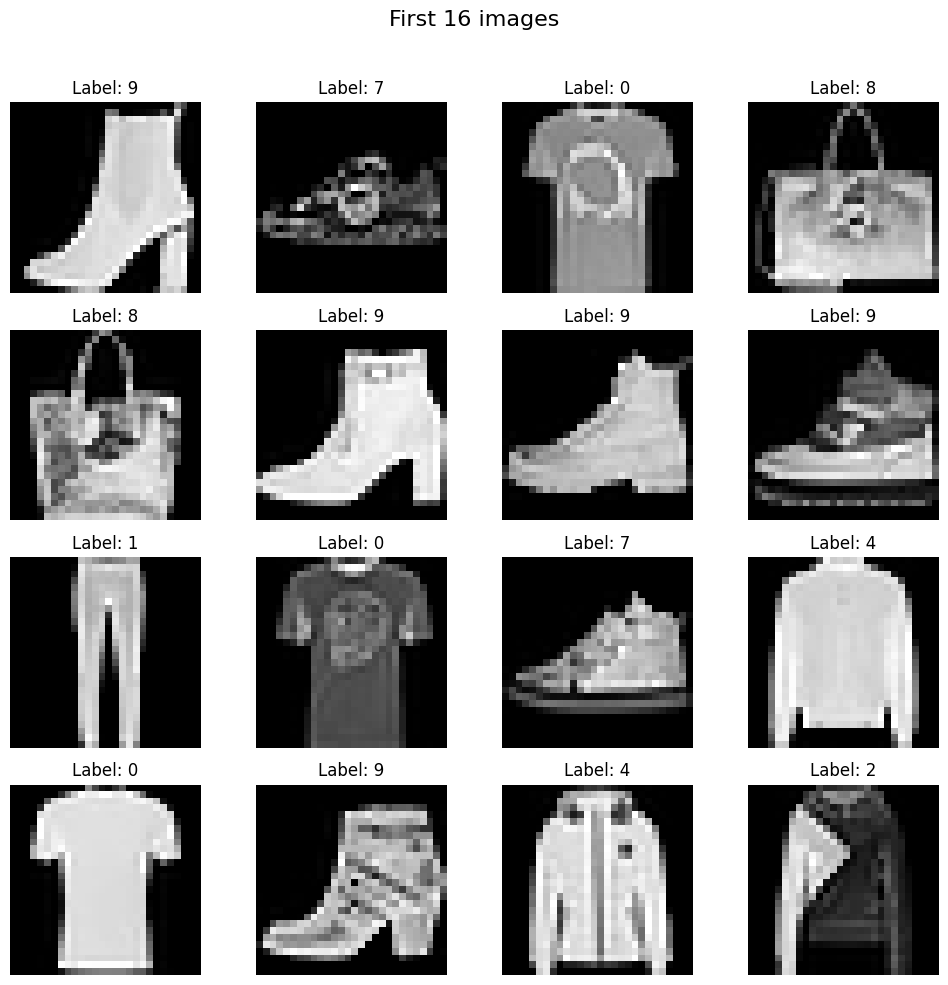

In [11]:
#create a 4x4 grid of images

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 images", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i, 0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [12]:
X = df.drop(columns=['label'])
y = df['label']


In [13]:
X.shape, y.shape

((6000, 784), (6000,))

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train = X_train/255.0
X_test = X_test/255.0

In [16]:
# Create customDataset class

class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features.values, dtype=torch.float32)
    self.labels = torch.tensor(labels.values, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    return self.features[idx], self.labels[idx]

In [17]:
#create train_dataset object

train_dataset = CustomDataset(X_train, y_train)

In [18]:
len(train_dataset)

4800

In [19]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [20]:
test_dataset = CustomDataset(X_test, y_test)

In [22]:
len(test_dataset)

1200

In [23]:
test_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [24]:
# create train and test loader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [27]:
# define NN Class

class MyNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
        #No need of softmax (default comes with cross entropy loss)
    )

  def forward(self, x):
    return self.model(x)

In [28]:
#set learning rate and epochs

epochs = 100
learning_rate = 0.1

In [29]:
#instatiate the model
model = MyNN(X_train.shape[1])

#loss function
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [30]:
#training loop

for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features , batch_labels in train_loader:
    #forward pass
    outputs = model(batch_features)

    #calculate loss
    loss = criterion(outputs, batch_labels)

    #zero-grad
    optimizer.zero_grad()

    #back-prop
    loss.backward()

    #update grads
    optimizer.step()

    total_epoch_loss += loss.item()

  print(f"Epoch : {epoch+1}, avg-loss: {total_epoch_loss/len(train_loader)}")


Epoch : 1, avg-loss: 1.3216368440786999
Epoch : 2, avg-loss: 0.7793365436792373
Epoch : 3, avg-loss: 0.6427524652083715
Epoch : 4, avg-loss: 0.5751657336950302
Epoch : 5, avg-loss: 0.528180201848348
Epoch : 6, avg-loss: 0.49528750121593473
Epoch : 7, avg-loss: 0.4602432996034622
Epoch : 8, avg-loss: 0.4359459094206492
Epoch : 9, avg-loss: 0.41829214423894884
Epoch : 10, avg-loss: 0.3984092291692893
Epoch : 11, avg-loss: 0.3850264506538709
Epoch : 12, avg-loss: 0.3722685620188713
Epoch : 13, avg-loss: 0.3477362078428268
Epoch : 14, avg-loss: 0.3467242218057315
Epoch : 15, avg-loss: 0.3138812760512034
Epoch : 16, avg-loss: 0.3126461291313171
Epoch : 17, avg-loss: 0.29552092105150224
Epoch : 18, avg-loss: 0.2857150869568189
Epoch : 19, avg-loss: 0.27084775785605114
Epoch : 20, avg-loss: 0.26237100958824155
Epoch : 21, avg-loss: 0.25756089876095456
Epoch : 22, avg-loss: 0.24232648963729542
Epoch : 23, avg-loss: 0.23957946779827277
Epoch : 24, avg-loss: 0.2261324493587017
Epoch : 25, avg-lo

In [31]:
#set model to eval mode

model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [33]:
# evaluation code

total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    outputs = model(batch_features)
    _, predicted = torch.max(outputs.data, 1)
    total += batch_labels.shape[0]
    correct += (predicted==batch_labels).sum().item()

print(f"Accuracy: {100*correct/total}")

Accuracy: 83.25


## Improvements in future videoes

1. use complete dataset (70k) with gpu
2. Optimizers, lr, epochs, weight_initialization_techniques, dropouts, batch_normalizations etc...
3. HyperParameter Tuning (Experiment with Architecture)